# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [3]:
from src.graphics import (plot_images, plot_class_distribution, plot_images_by_class, plot_mean_image_by_class,
                          plot_cumulative_variance, plot_k_means_inertia_analysis,
                          plot_gmm_log_likelihood_comparison, plot_clustering_k_analysis,
                          plot_tsne_cluster_comparison, plot_cluster_class_heatmap_comparison,
                        plot_cluster_size_comparison, plot_cluster_purity_comparison, plot_images_by_cluster)

from src.utils import (build_class_summary, run_k_means_for_k_range, display_k_means_comparison,
                       run_gmm_for_k_range, display_gmm_comparison, compute_silhouette_for_k_range,
                       build_cluster_size_table, build_cluster_class_table, build_cluster_purity_table)

from src.data_splitting import stratified_train_eval_split, stratified_sample_selection
from src.preprocessing import standardize, inverse_standardize
from src.pca import fit_pca, transform_pca, reconstruct_pca
from src.models import Autoencoder

from src.torch_utils import (train_autoencoder, reconstruct_autoencoder, compute_reconstruction_metrics,
                             encode_autoencoder)

from src.clustering import compute_marginal_gain
from src.tsne import tsne

In [4]:
dataset = pd.read_csv("data/fashion_mnist_subset.csv")

## 1. Inspección de los datos

In [5]:
print(dataset.columns)

Index(['pixel_0', 'pixel_1', 'pixel_2', 'pixel_3', 'pixel_4', 'pixel_5',
       'pixel_6', 'pixel_7', 'pixel_8', 'pixel_9',
       ...
       'pixel_775', 'pixel_776', 'pixel_777', 'pixel_778', 'pixel_779',
       'pixel_780', 'pixel_781', 'pixel_782', 'pixel_783', 'label'],
      dtype='str', length=785)


In [6]:
# Separacion entre pixeles y etiquetas
y = dataset["label"]
X = dataset.drop(columns = ["label"])

In [7]:
print("Shape del dataset completo:", dataset.shape)
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases presentes:", np.unique(y))
print("Rango de pixeles:", X.values.min(), "a", X.values.max())

Shape del dataset completo: (25000, 785)
Shape de X: (25000, 784)
Shape de y: (25000,)
Clases presentes: [0 1 2 3 4 5 6 7 8 9]
Rango de pixeles: 0.0 a 1.0


El conjunto de datos utilizado corresponde a un subconjunto de Fashion-MNIST, una base de imágenes de prendas de vestir y accesorios. Cada observación representa una imagen en escala de grises de $28 \times 28$ píxeles, almacenada como un vector de 784 variables, donde cada variable indica la intensidad de un píxel. Los valores de los píxeles se encuentran normalizados en el rango $[0,1]$, donde valores cercanos a 0 representan píxeles oscuros y valores cercanos a 1 representan píxeles claros.

Además, cada imagen cuenta con una etiqueta numérica que indica su clase real: 0 corresponde a remera/top, 1 a pantalón, 2 a pulóver, 3 a vestido, 4 a abrigo, 5 a sandalia, 6 a camisa, 7 a zapatilla, 8 a bolso y 9 a bota. Dado que el objetivo del trabajo es aplicar técnicas de aprendizaje no supervisado, estas etiquetas no se utilizan para entrenar los modelos, sino únicamente como referencia externa para interpretar y evaluar los resultados obtenidos.

### a) Visualización de imágenes

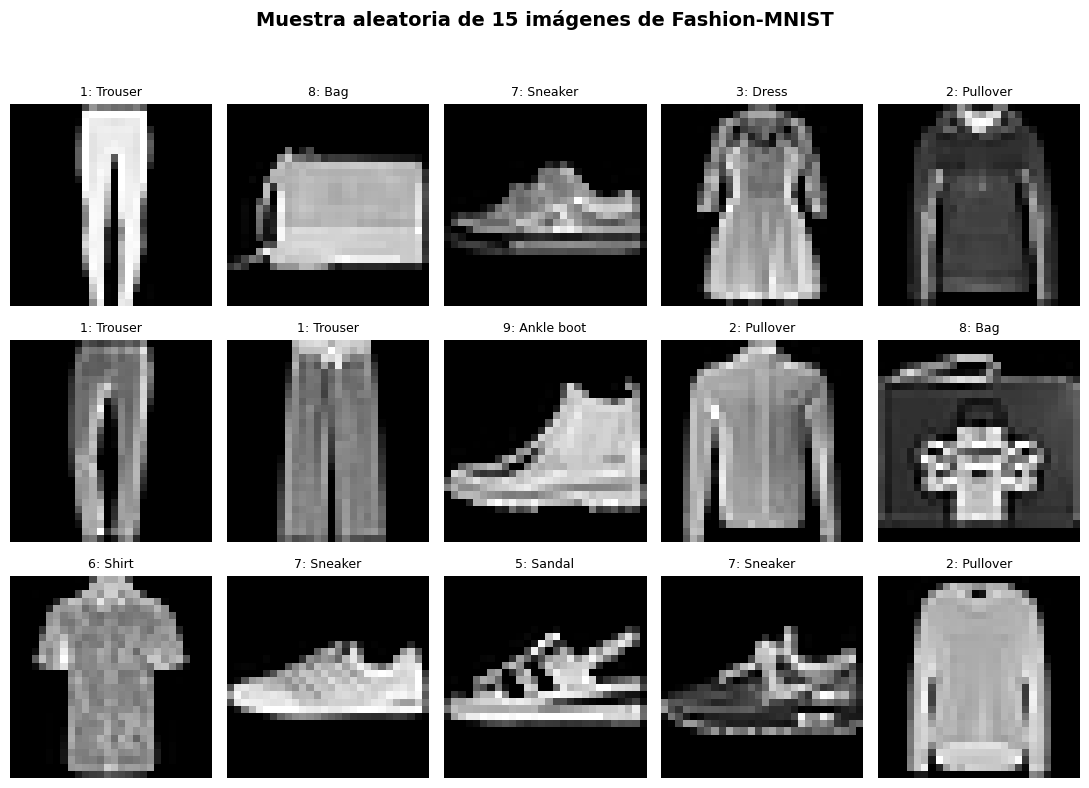

In [8]:
plot_images(X, y, n_images = 15, title = "Muestra aleatoria de 15 imágenes de Fashion-MNIST") 

### b) Análisis Exploratorio de Datos

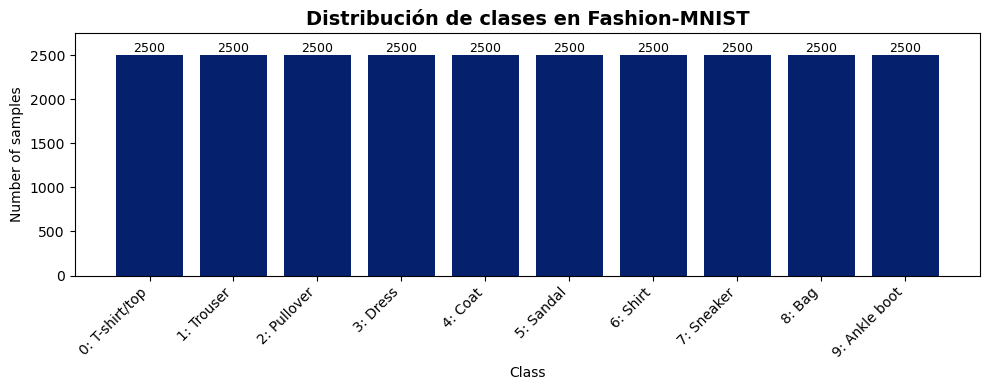

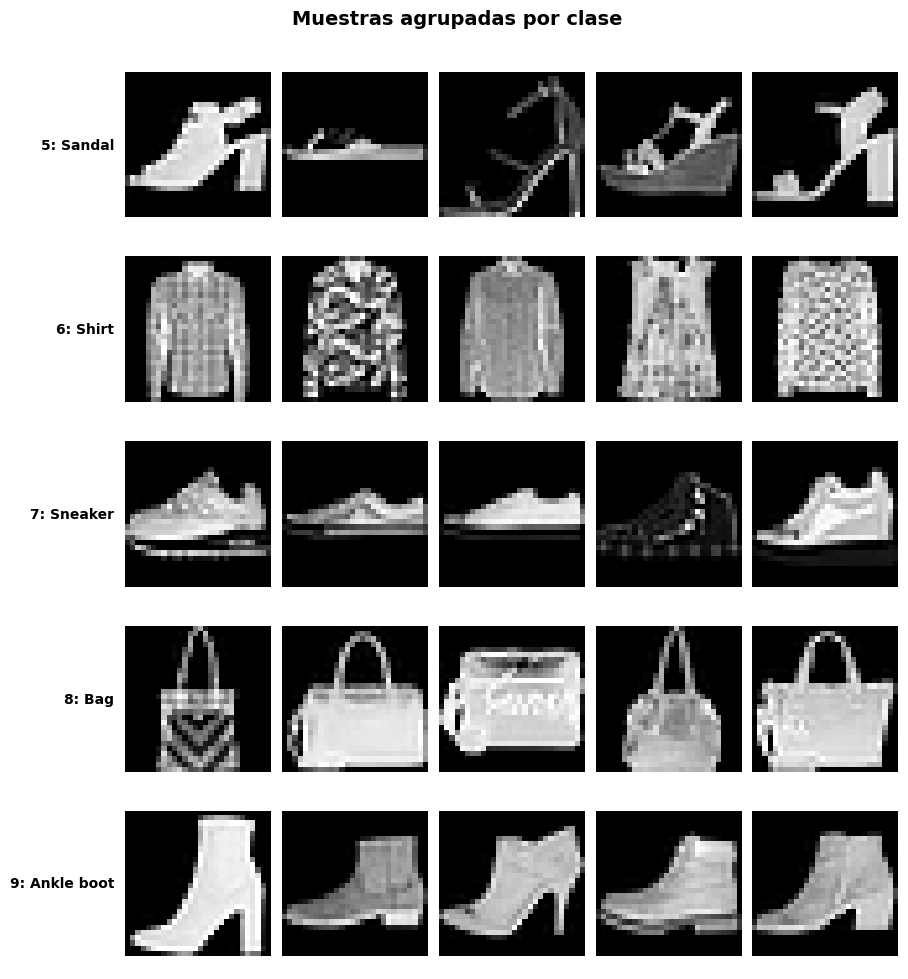

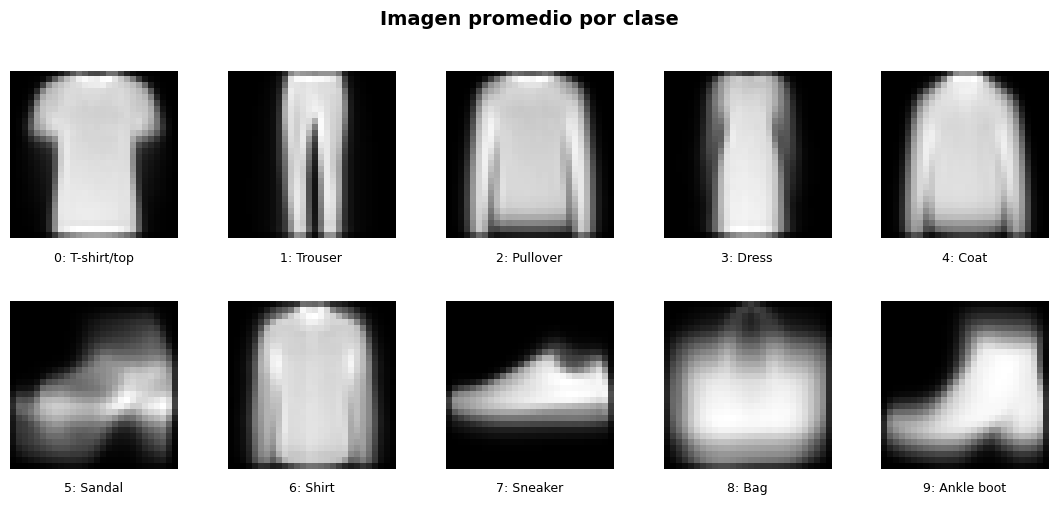

,class_name,count,percentage,mean_intensity,std_intensity,mean_nonzero_pixels
0,T-shirt/top,2500,10.0,0.3284,0.3515,465.99
1,Trouser,2500,10.0,0.2232,0.3437,274.03
2,Pullover,2500,10.0,0.3726,0.3566,507.36
3,Dress,2500,10.0,0.2576,0.3537,335.21
4,Coat,2500,10.0,0.3880,0.3772,472.64
5,Sandal,2500,10.0,0.1378,0.2643,252.65
6,Shirt,2500,10.0,0.3335,0.3409,493.09
7,Sneaker,2500,10.0,0.1684,0.2959,264.23
8,Bag,2500,10.0,0.3557,0.3654,461.16
9,Ankle boot,2500,10.0,0.3008,0.3708,379.03


In [9]:
class_counts = plot_class_distribution(y, title = "Distribución de clases en Fashion-MNIST")
plot_images_by_class(X, y, classes = [5, 6, 7, 8, 9], n_per_class = 5, title = "Muestras agrupadas por clase")
plot_mean_image_by_class(X, y)
build_class_summary(X, y)

In [10]:
print("=== Estadísticas del dataset ===")
print("Cantidad de pixeles por imagen:", X.shape[1])
print("Cantidad de clases:", y.nunique())
print("Diferencia entre clase mayoritaria y minoritaria:", class_counts.max() - class_counts.min())
print("Proporcion minima:", round(class_counts.min() / len(y), 4))
print("Proporcion maxima:", round(class_counts.max() / len(y), 4))
print("Valores faltantes en X:", X.isna().sum().sum())
print("Valores faltantes en y:", y.isna().sum())
print("Promedio global de intensidad:", round(X.to_numpy().mean(), 4))
print("Desvio global de intensidad:", round(X.to_numpy().std(), 4))
print("Porcentaje de pixeles en cero:", round((X.eq(0).sum().sum() / X.size) * 100, 2), "%")

=== Estadísticas del dataset ===
Cantidad de pixeles por imagen: 784
Cantidad de clases: 10
Diferencia entre clase mayoritaria y minoritaria: 0
Proporcion minima: 0.1
Proporcion maxima: 0.1
Valores faltantes en X: 0
Valores faltantes en y: 0
Promedio global de intensidad: 0.2866
Desvio global de intensidad: 0.3533
Porcentaje de pixeles en cero: 50.19 %


A partir de los gráficos y la tabla, se observa que el dataset está perfectamente balanceado: cada una de las 10 clases tiene 2500 imágenes, es decir, representa el 10% del total. Esto es importante porque ninguna clase queda sobrerrepresentada, por lo que los métodos de agrupamiento no deberían verse influenciados por diferencias en la cantidad de ejemplos.

Al mirar las muestras agrupadas por clase, aparece bastante variabilidad dentro de una misma etiqueta. Esto se nota especialmente en sandalias, zapatillas, botas y bolsos, donde cambian las formas, orientaciones y estilos. Por este motivo, no sería raro que algunos métodos no supervisados tengan dificultades para separar las observaciones exactamente según las etiquetas originales.

Las imágenes promedio permiten ver la forma típica de cada categoría. Algunas clases, como pantalón, zapatilla, bolso y bota, tienen siluetas bastante distinguibles. En cambio, prendas como remera/top, pulóver, abrigo y camisa son visualmente más parecidas entre sí, lo que podría hacer más difícil diferenciarlas.

Por último, la tabla muestra que las clases ocupan distintas proporciones de la imagen. Sandalias y zapatillas tienen menos píxeles blancos y una intensidad promedio más baja, mientras que pulóveres, abrigos y camisas ocupan una mayor área visual.

### c) Separando los datos

In [11]:
(xtr, ytr), (xeval, yeval) = stratified_train_eval_split(X, y, eval_size = 0.20)

In [12]:
print("X_train:", xtr.shape)
print("y_train:", ytr.shape)
print("X_eval:", xeval.shape)
print("y_eval:", yeval.shape)

X_train: (20000, 784)
y_train: (20000,)
X_eval: (5000, 784)
y_eval: (5000,)


## 2. Reducción de Dimensionalidad

### a) Estandarizando y aplicando PCA

PCA, o Análisis de Componentes Principales, es una técnica de reducción de dimensionalidad. La idea principal es transformar los datos originales en un nuevo conjunto de variables, llamadas componentes principales, que resumen la mayor parte de la información posible.

En este caso, cada imagen tiene 784 variables, una por cada píxel. Muchas de estas variables pueden estar relacionadas entre sí o aportar información parecida. PCA busca nuevas direcciones en los datos donde haya mayor variabilidad, y ordena esas direcciones desde la más importante hasta la menos importante.

De esta forma, en lugar de trabajar con los 784 píxeles originales, podemos quedarnos con una cantidad menor de componentes principales que expliquen gran parte de la variabilidad del dataset. Esto permite simplificar los datos, reducir el costo computacional y, al mismo tiempo, conservar la estructura más importante de las imágenes.

In [13]:
# Standardize
xtr_std, xtr_mean, xtr_std_val = standardize(xtr)
xeval_std = standardize(xeval, train = False, xtr_mean = xtr_mean, xtr_std = xtr_std_val)

In [14]:
# Applying PCA
xtr_pca, pca_params = fit_pca(xtr_std, variance_threshold = 0.95) # Using default variance threshold
xeval_pca = transform_pca(xeval_std, pca_params)

In [15]:
print("=== Resultados de PCA ===")
print("Dimensiones originales de entrenamiento:", xtr.shape)
print("Dimensiones con PCA de entrenamiento:", xtr_pca.shape)
print()
print("Dimensiones originales de evaluación:", xeval.shape)
print("Dimensiones con PCA de evaluación:", xeval_pca.shape)
print()
print("Cantidad de componentes seleccionadas:", pca_params["m_components"])
print("Varianza explicada acumulada:", round(pca_params["cumulative_variance_ratio"][pca_params["m_components"] - 1], 4))

=== Resultados de PCA ===
Dimensiones originales de entrenamiento: (20000, 784)
Dimensiones con PCA de entrenamiento: (20000, 252)

Dimensiones originales de evaluación: (5000, 784)
Dimensiones con PCA de evaluación: (5000, 252)

Cantidad de componentes seleccionadas: 252
Varianza explicada acumulada: 0.9502


### b) Varianza explicada acumulada vs componentes (90% de varianza explicada)

In [16]:
xtr_pca_90, pca_params_90 = fit_pca(xtr_std, variance_threshold = 0.90)
xeval_pca_90 = transform_pca(xeval_std, pca_params_90)

In [17]:

xeval_reconstructed_std = reconstruct_pca(xeval_pca_90, pca_params_90)
xeval_reconstructed_pca = inverse_standardize(xeval_reconstructed_std, xtr_mean, xtr_std_val)

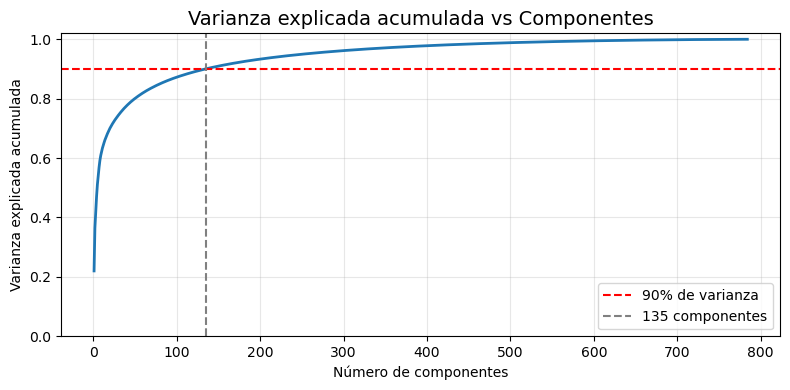

=== Resultados de PCA (90%) ===
Dimensiones originales de entrenamiento: (20000, 784)
Dimensiones con PCA de entrenamiento: (20000, 135)

Dimensiones originales de evaluación: (5000, 784)
Dimensiones con PCA de evaluación: (5000, 135)

Cantidad de componentes seleccionadas: 135
Varianza explicada acumulada: 0.9004


In [18]:
plot_cumulative_variance(pca_params_90, variance_threshold = 0.90)
print("=== Resultados de PCA (90%) ===")
print("Dimensiones originales de entrenamiento:", xtr.shape)
print("Dimensiones con PCA de entrenamiento:", xtr_pca_90.shape)
print()
print("Dimensiones originales de evaluación:", xeval.shape)
print("Dimensiones con PCA de evaluación:", xeval_pca_90.shape)
print()
print("Cantidad de componentes seleccionadas:", pca_params_90["m_components"])
print("Varianza explicada acumulada:", round(pca_params_90["cumulative_variance_ratio"][pca_params_90["m_components"] - 1], 4))

### Imagen original vs imagen reconstruida

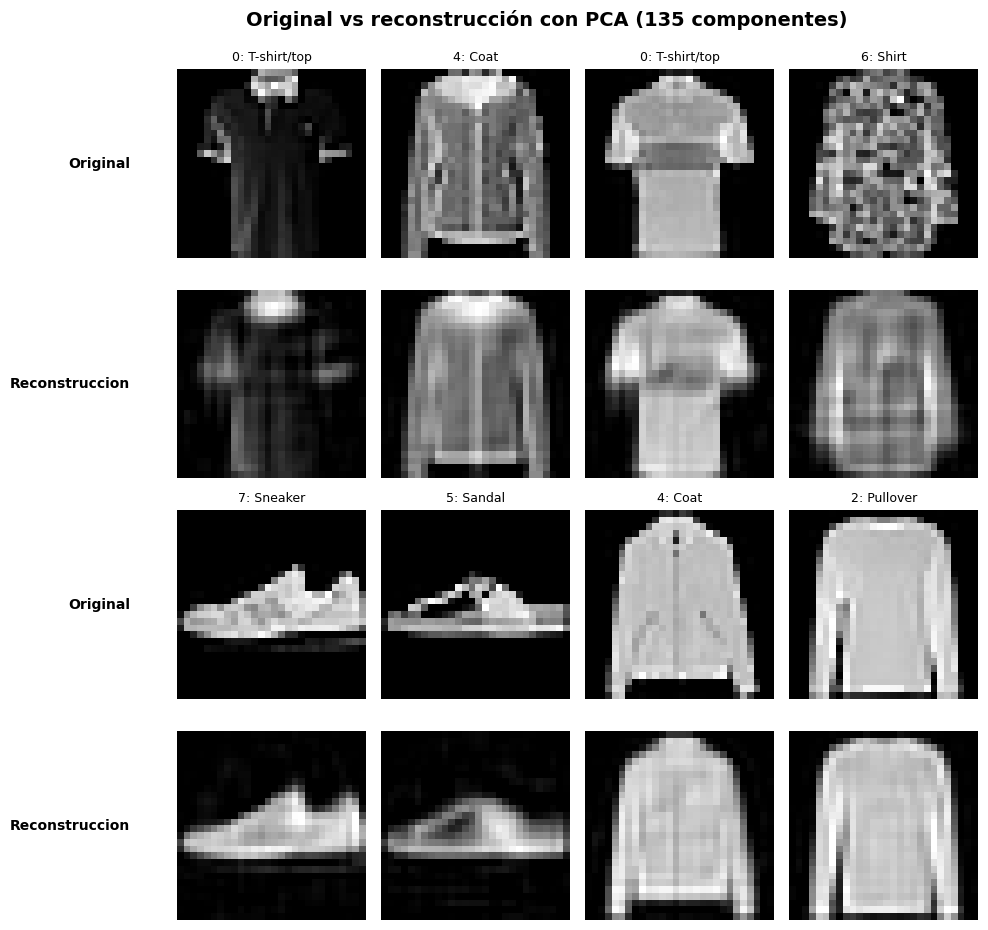

=== Error de reconstrucción ===
MSE: 0.008091
RMSE: 0.089949
MAE: 0.054488
Error minimo por imagen: 0.001379
Error promedio por imagen: 0.008091
Error maximo por imagen: 0.0812


In [19]:
comp = pca_params_90["m_components"]
plot_images(xeval, yeval, n_images = 8, compare_with = xeval_reconstructed_pca, n_cols = 4, title = f"Original vs reconstrucción con PCA ({comp} componentes)")

# Reconstruction metrics
xeval_values = xeval.to_numpy() if hasattr(xeval, "to_numpy") else np.asarray(xeval)
xeval_reconstructed_pca_values = xeval_reconstructed_pca.to_numpy() if hasattr(xeval_reconstructed_pca, "to_numpy") else np.asarray(xeval_reconstructed_pca)

reconstruction_mse = np.mean((xeval_values - xeval_reconstructed_pca_values) ** 2)
reconstruction_rmse = np.sqrt(reconstruction_mse)
mean_absolute_error = np.mean(np.abs(xeval_values - xeval_reconstructed_pca_values))

print("=== Error de reconstrucción ===")
print("MSE:", round(reconstruction_mse, 6))
print("RMSE:", round(reconstruction_rmse, 6))
print("MAE:", round(mean_absolute_error, 6))

reconstruction_error_per_image = np.mean((xeval_values - xeval_reconstructed_pca_values) ** 2, axis=1)

print("Error minimo por imagen:", round(reconstruction_error_per_image.min(), 6))
print("Error promedio por imagen:", round(reconstruction_error_per_image.mean(), 6))
print("Error maximo por imagen:", round(reconstruction_error_per_image.max(), 6))

Al comparar las imágenes originales con las reconstruidas, se nota que las segundas pierden nitidez y se ven más borrosas. Esto es esperable, porque pasamos de representar cada imagen con 784 píxeles a usar solo 135 componentes principales.

Aun así, la forma general de las prendas se mantiene bastante bien. En la mayoría de los casos todavía se puede reconocer qué tipo de objeto es, aunque se pierdan detalles como texturas, bordes o contrastes.

Los errores de reconstrucción también acompañan esta idea: el MSE fue 0.0081, el RMSE 0.0899 y el MAE 0.0545. Como los píxeles están en el rango $[0,1]$, estos valores son relativamente bajos. Entonces, con el 90% de la varianza, PCA logra reducir mucho la cantidad de variables sin perder la información visual más importante.

### c) Modelo Autoencoder Deterministico (AE)

In [20]:
# Define latent dimension
latent_dim = pca_params_90["m_components"]

In [21]:
# Convert data into tensors
xtr_tensor = torch.tensor(xtr.to_numpy(), dtype=torch.float32)
xeval_tensor = torch.tensor(xeval.to_numpy(), dtype=torch.float32)

In [22]:
# Build Datasets
train_dataset = TensorDataset(xtr_tensor, xtr_tensor)
eval_dataset = TensorDataset(xeval_tensor, xeval_tensor)

train_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True)
eval_loader = DataLoader(eval_dataset, batch_size = 128, shuffle = False)

In [23]:
# Set seed and device
seed = 42

np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [24]:
# Define autoencoder
autoencoder = Autoencoder(input_size = 784, latent_dim = latent_dim, hidden_nodes = [512, 256], 
                          activation = "relu")

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr = 0.001)

El autoencoder se entrenó minimizando el error de reconstrucción mediante `MSELoss`. Esta pérdida corresponde al promedio de los errores cuadrados entre la imagen original y su reconstrucción. Es equivalente, salvo por una constante de escala, a minimizar la suma de las normas al cuadrado $\sum_i \|x_i - \hat{x}_i\|^2$ por lo que mantiene el mismo objetivo de optimización.

In [25]:
print("Dimensión latente:", latent_dim)

Dimensión latente: 135


In [26]:
# Train autoencoder
history_ae = train_autoencoder(autoencoder, train_loader, eval_loader, loss_fn, optimizer,
                               epochs = 30, device = device, verbose = True)

Epoch 1/30 - train loss: 0.055556 - eval loss: 0.034872
Epoch 2/30 - train loss: 0.027083 - eval loss: 0.023173
Epoch 3/30 - train loss: 0.022058 - eval loss: 0.020779
Epoch 4/30 - train loss: 0.020294 - eval loss: 0.019335
Epoch 5/30 - train loss: 0.018881 - eval loss: 0.018244
Epoch 6/30 - train loss: 0.017558 - eval loss: 0.017461
Epoch 7/30 - train loss: 0.016690 - eval loss: 0.016155
Epoch 8/30 - train loss: 0.015857 - eval loss: 0.016122
Epoch 9/30 - train loss: 0.015203 - eval loss: 0.015034
Epoch 10/30 - train loss: 0.014610 - eval loss: 0.014397
Epoch 11/30 - train loss: 0.014125 - eval loss: 0.014303
Epoch 12/30 - train loss: 0.013650 - eval loss: 0.013659
Epoch 13/30 - train loss: 0.013286 - eval loss: 0.013264
Epoch 14/30 - train loss: 0.012887 - eval loss: 0.013059
Epoch 15/30 - train loss: 0.012609 - eval loss: 0.013198
Epoch 16/30 - train loss: 0.012299 - eval loss: 0.012532
Epoch 17/30 - train loss: 0.012100 - eval loss: 0.012297
Epoch 18/30 - train loss: 0.011792 - eva

In [27]:
# Reconstruct and evaluate metrics
xeval_reconstructed_ae = reconstruct_autoencoder(autoencoder, xeval, device)
ae_metrics = compute_reconstruction_metrics(xeval, xeval_reconstructed_ae)

In [28]:
print("=== Error de reconstrucción AE ===")
print("MSE:", round(ae_metrics["mse"], 6))
print("RMSE:", round(ae_metrics["rmse"], 6))
print("MAE:", round(ae_metrics["mae"], 6))

xeval_values = xeval.to_numpy() if hasattr(xeval, "to_numpy") else np.asarray(xeval)
xeval_reconstructed_values = xeval_reconstructed_ae.to_numpy() if hasattr(xeval_reconstructed_ae, "to_numpy") else np.asarray(xeval_reconstructed_ae)

reconstruction_error_per_image = np.mean((xeval_values - xeval_reconstructed_values) ** 2, axis=1)

print("Error minimo por imagen:", round(reconstruction_error_per_image.min(), 6))
print("Error promedio por imagen:", round(reconstruction_error_per_image.mean(), 6))
print("Error maximo por imagen:", round(reconstruction_error_per_image.max(), 6))

=== Error de reconstrucción AE ===
MSE: 0.010311
RMSE: 0.101545
MAE: 0.052157
Error minimo por imagen: 0.000743
Error promedio por imagen: 0.010311
Error maximo por imagen: 0.091854


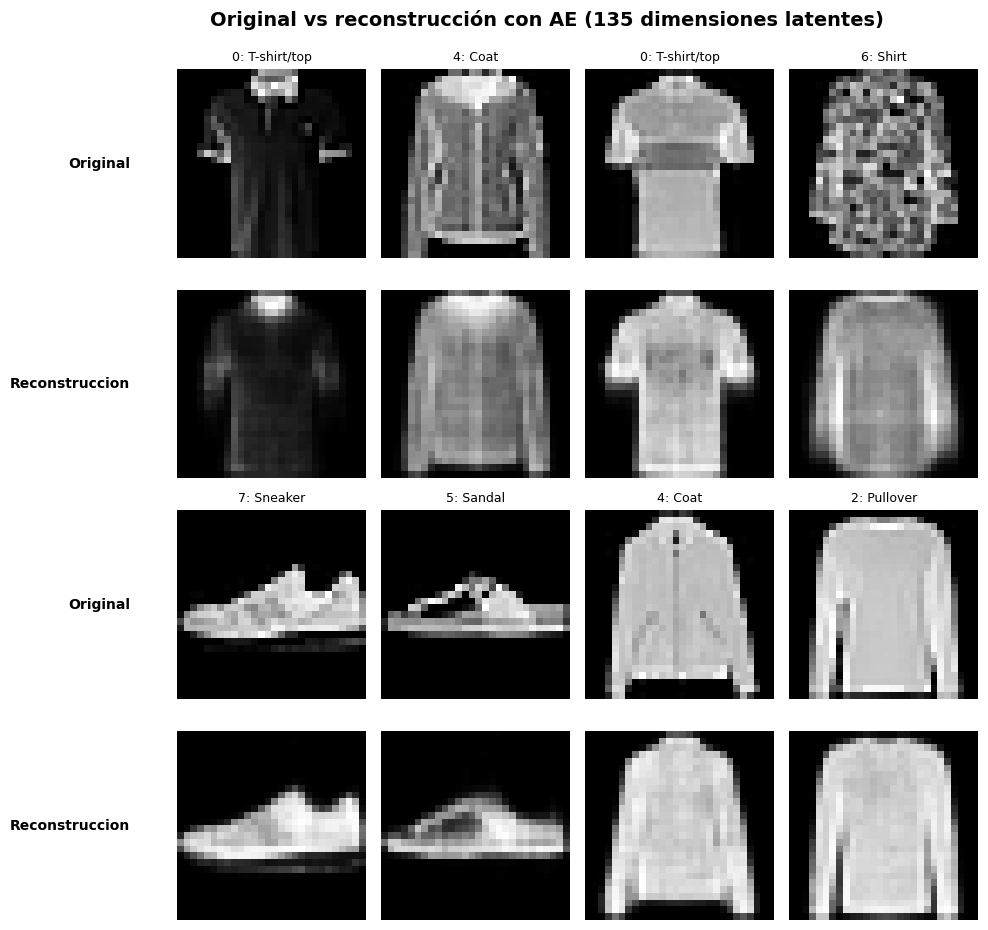

In [29]:
plot_images(xeval, yeval, n_images = 8, compare_with = xeval_reconstructed_ae, n_cols = 4,
            title = f"Original vs reconstrucción con AE ({latent_dim} dimensiones latentes)")

### d) PCA vs AE

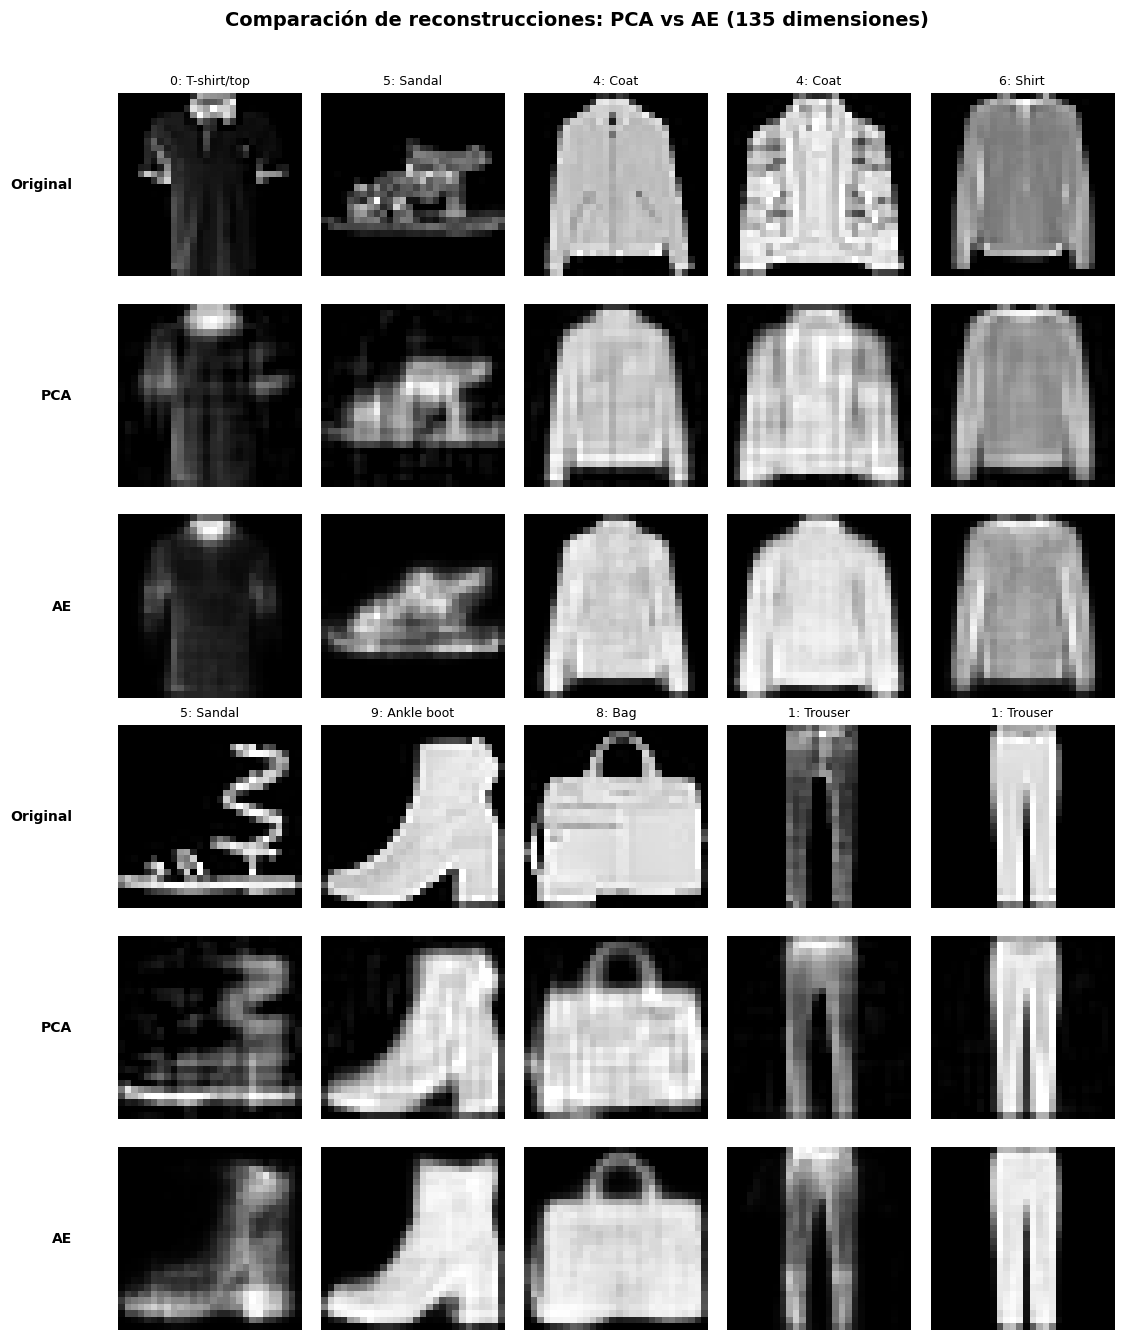

In [30]:
rng = np.random.default_rng(42)
comparison_indices = rng.choice(len(xeval), size = 10, replace = False)

plot_images(xeval, yeval, indices = comparison_indices, compare_with = [xeval_reconstructed_pca, xeval_reconstructed_ae],
            comparison_labels = ("Original", "PCA", "AE"), n_cols = 5, title = f"Comparación de reconstrucciones: PCA vs AE ({latent_dim} dimensiones)")

Comparando las reconstrucciones, se ve que ambos métodos logran conservar la forma general de las prendas. Las imágenes reconstruidas pierden nitidez y detalles, pero en la mayoría de los casos todavía se puede reconocer qué objeto era.

PCA tuvo un MSE de 0.0081 y un RMSE de 0.0899, mientras que el autoencoder tuvo un MSE de 0.0103 y un RMSE de 0.1015. En estas métricas, PCA reconstruyó un poco mejor. Sin embargo, el MAE fue levemente menor en el autoencoder: 0.0522 frente a 0.0545 en PCA. Esto muestra que la diferencia entre los dos métodos no es enorme, pero PCA tuvo una pequeña ventaja en el error cuadrático.

Visualmente, PCA tiende a generar imágenes más borrosas y un poco mas ruuidosas. El autoencoder pierde un poc mas de detalle, pero en ambos casos se mantiene bastante bien la silueta general. Usando la misma dimensión latente de 135, ambos métodos reducen la dimensionalidad y conservan la información principal, aunque en este caso PCA obtuvo una reconstrucción ligeramente mejor según MSE y RMSE.

### e) Transformando los datos en el nuevo espacio latente

In [31]:
xtr_ae_latent = encode_autoencoder(autoencoder, xtr, device)
xeval_ae_latent = encode_autoencoder(autoencoder, xeval, device)

In [32]:

print("Latente PCA train:", xtr_pca_90.shape)
print("Latente PCA eval:", xeval_pca_90.shape)
print("Latente AE train:", xtr_ae_latent.shape)
print("Latente AE eval:", xeval_ae_latent.shape)

Latente PCA train: (20000, 135)
Latente PCA eval: (5000, 135)
Latente AE train: (20000, 135)
Latente AE eval: (5000, 135)


## 3. Clustering

In [33]:
# Stratified sample
n_samples = 3000

xtr_pca_sample, ytr_sample, sample_indices = stratified_sample_selection(xtr_pca_90, ytr, n_samples)
xtr_ae_sample = xtr_ae_latent[sample_indices]

In [34]:
k_values = range(5, 16)

### a) K-Means

In [35]:
kmeans_pca_results = run_k_means_for_k_range(xtr_pca_sample, k_values, init = "kmeans++")

Convergencia alcanzada en la iteración 13
K=5 | inertia=1323566.10 | iterations=14
Convergencia alcanzada en la iteración 30
K=6 | inertia=1231029.71 | iterations=31
Convergencia alcanzada en la iteración 32
K=7 | inertia=1163258.42 | iterations=33
Convergencia alcanzada en la iteración 39
K=8 | inertia=1120578.02 | iterations=40
Convergencia alcanzada en la iteración 22
K=9 | inertia=1099007.33 | iterations=23
Convergencia alcanzada en la iteración 47
K=10 | inertia=1061775.72 | iterations=48
Convergencia alcanzada en la iteración 36
K=11 | inertia=1046095.01 | iterations=37
Convergencia alcanzada en la iteración 30
K=12 | inertia=1013504.82 | iterations=31
Convergencia alcanzada en la iteración 17
K=13 | inertia=994532.48 | iterations=18
Convergencia alcanzada en la iteración 19
K=14 | inertia=981344.84 | iterations=20
Convergencia alcanzada en la iteración 29
K=15 | inertia=953989.02 | iterations=30


In [36]:
kmeans_ae_results = run_k_means_for_k_range(xtr_ae_sample, k_values, init = "kmeans++")

Convergencia alcanzada en la iteración 17
K=5 | inertia=191169.88 | iterations=18
Convergencia alcanzada en la iteración 27
K=6 | inertia=182270.91 | iterations=28
Convergencia alcanzada en la iteración 38
K=7 | inertia=177671.97 | iterations=39
Convergencia alcanzada en la iteración 35
K=8 | inertia=169956.14 | iterations=36
Convergencia alcanzada en la iteración 46
K=9 | inertia=165446.06 | iterations=47
Convergencia alcanzada en la iteración 24
K=10 | inertia=159855.16 | iterations=25
Convergencia alcanzada en la iteración 20
K=11 | inertia=156361.52 | iterations=21
Convergencia alcanzada en la iteración 19
K=12 | inertia=148967.66 | iterations=20
Convergencia alcanzada en la iteración 20
K=13 | inertia=146796.69 | iterations=21
Convergencia alcanzada en la iteración 35
K=14 | inertia=144350.78 | iterations=36
Convergencia alcanzada en la iteración 44
K=15 | inertia=142927.45 | iterations=45


K,PCA inertia,PCA iterations,AE inertia,AE iterations
5,1323566.100883,14,191169.875000,18
6,1231029.712286,31,182270.906250,28
7,1163258.415911,33,177671.968750,39
8,1120578.018880,40,169956.140625,36
9,1099007.329994,23,165446.062500,47
10,1061775.722220,48,159855.156250,25
11,1046095.014708,37,156361.515625,21
12,1013504.821935,31,148967.656250,20
13,994532.475974,18,146796.687500,21
14,981344.835690,20,144350.781250,36


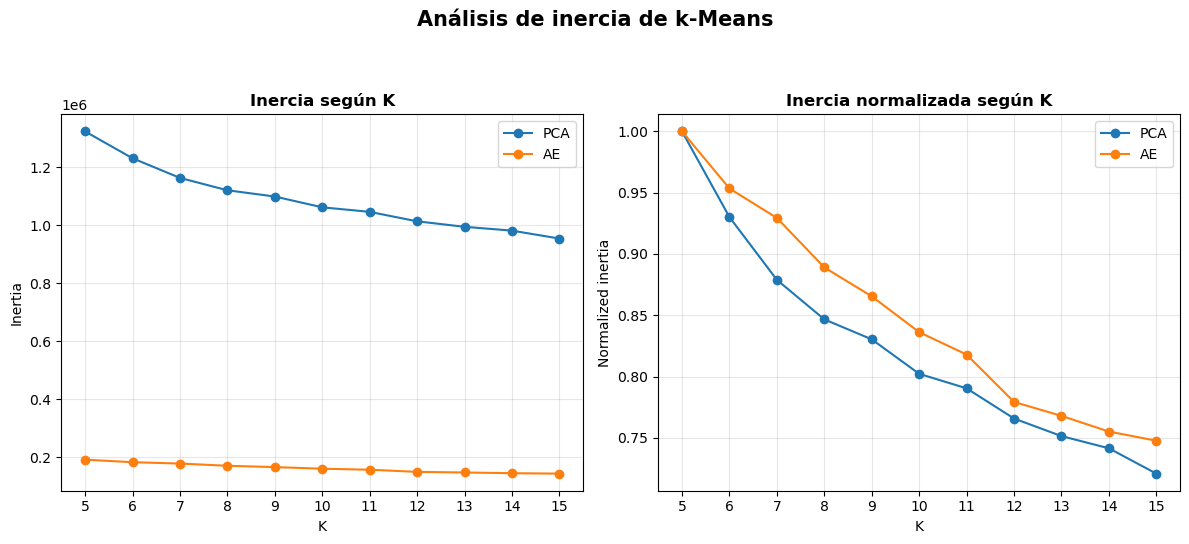

In [37]:
display_k_means_comparison(kmeans_pca_results, kmeans_ae_results)
plot_k_means_inertia_analysis(kmeans_pca_results, kmeans_ae_results)

En k-Means se usa la inercia para medir qué tan compactos son los clusters. Esta métrica suma las distancias cuadradas entre cada punto y el centroide del cluster al que fue asignado. Entonces, cuanto menor es la inercia, más cerca están los puntos de sus centroides.

Al aumentar $K$, la inercia baja, porque el modelo tiene más centroides para repartir los datos. Esto se ve tanto en PCA como en AE. Sin embargo, para comparar ambas curvas se usó la inercia normalizada, porque la inercia depende mucho de la escala de los datos. Aunque PCA y AE tienen la misma cantidad de dimensiones, sus valores latentes no necesariamente están en la misma escala. Por eso, comparar la inercia cruda puede ser engañoso.

Con la normalización, cada curva empieza en 1 y se observa la mejora relativa al aumentar $K$. En ambos casos, la inercia disminuye más al principio y luego la caída se vuelve más suave, lo que sugiere que agregar más clusters empieza a aportar cada vez menos.

### b) GMM

In [38]:
gmm_pca_results = run_gmm_for_k_range(xtr_pca_sample, k_values)

K=5 | log_likelihood=-620333.67 | iterations=119
K=6 | log_likelihood=-613126.57 | iterations=200
K=7 | log_likelihood=-612206.43 | iterations=131
K=8 | log_likelihood=-611909.12 | iterations=116
K=9 | log_likelihood=-603717.92 | iterations=200
K=10 | log_likelihood=-603428.76 | iterations=200
K=11 | log_likelihood=-602725.11 | iterations=194
K=12 | log_likelihood=-599347.83 | iterations=186
K=13 | log_likelihood=-599508.57 | iterations=186
K=14 | log_likelihood=-595386.38 | iterations=165
K=15 | log_likelihood=-595607.77 | iterations=200


In [39]:
gmm_ae_results = run_gmm_for_k_range(xtr_ae_sample, k_values)

K=5 | log_likelihood=-389508.99 | iterations=69
K=6 | log_likelihood=-379965.60 | iterations=105
K=7 | log_likelihood=-369770.42 | iterations=120
K=8 | log_likelihood=-367444.85 | iterations=79
K=9 | log_likelihood=-355915.51 | iterations=72
K=10 | log_likelihood=-352278.15 | iterations=103
K=11 | log_likelihood=-343221.32 | iterations=87
K=12 | log_likelihood=-335526.11 | iterations=145
K=13 | log_likelihood=-328442.37 | iterations=112
K=14 | log_likelihood=-322991.19 | iterations=200
K=15 | log_likelihood=-323441.00 | iterations=109


K,PCA log-likelihood,PCA iterations,AE log-likelihood,AE iterations
5,-620333.668437,119,-389508.986691,69
6,-613126.574029,200,-379965.598154,105
7,-612206.430596,131,-369770.419397,120
8,-611909.118251,116,-367444.852180,79
9,-603717.921970,200,-355915.510587,72
10,-603428.760638,200,-352278.151633,103
11,-602725.106002,194,-343221.319640,87
12,-599347.834948,186,-335526.109662,145
13,-599508.573696,186,-328442.367070,112
14,-595386.381590,165,-322991.188457,200


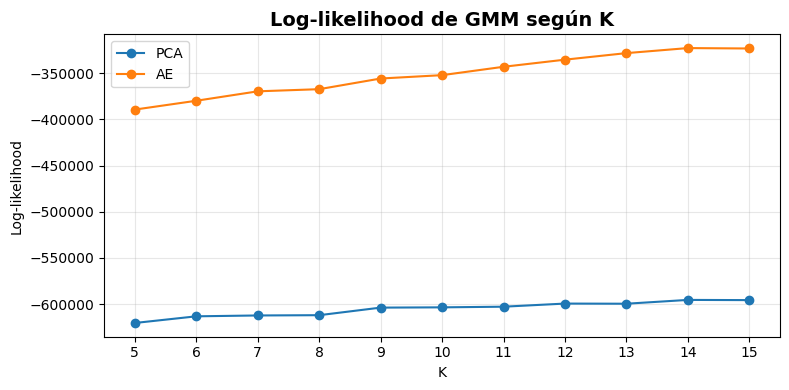

In [40]:
display_gmm_comparison(gmm_pca_results, gmm_ae_results)
plot_gmm_log_likelihood_comparison(gmm_pca_results, gmm_ae_results)

En GMM se usa el log-likelihood para medir qué tan bien el modelo probabilístico explica los datos. Como GMM representa los datos como una mezcla de gaussianas, el log-likelihood indica qué tan probable es observar los puntos bajo las componentes aprendidas. En este caso, valores más altos significan un mejor ajuste.

Al aumentar $K$, el log-likelihood tiende a subir, porque el modelo tiene más componentes gaussianas y puede adaptarse mejor a los datos. Esto se observa tanto en PCA como en AE. Aun así, no alcanza con elegir el mayor $K$, porque más componentes casi siempre mejoran el ajuste.

A diferencia de la inercia, no normalicé el log-likelihood de la misma forma, porque puede tomar valores negativos y su escala depende de la densidad del modelo. Para analizarlo mejor, conviene mirar la ganancia marginal: cuánto mejora el log-likelihood al pasar de un $K$ al siguiente.

### c) Ganancias decrecientes Y Silhouette score

In [41]:
kmeans_pca_gain = compute_marginal_gain(kmeans_pca_results, metric="inertia", mode="decrease")
kmeans_ae_gain = compute_marginal_gain(kmeans_ae_results, metric="inertia", mode="decrease")

In [42]:
kmeans_pca_silhouette = compute_silhouette_for_k_range(xtr_pca_sample, kmeans_pca_results)
kmeans_ae_silhouette = compute_silhouette_for_k_range(xtr_ae_sample, kmeans_ae_results)

K=5 | silhouette=0.1592
K=6 | silhouette=0.1556
K=7 | silhouette=0.1536
K=8 | silhouette=0.1492
K=9 | silhouette=0.1426
K=10 | silhouette=0.1378
K=11 | silhouette=0.1393
K=12 | silhouette=0.1387
K=13 | silhouette=0.1294
K=14 | silhouette=0.1296
K=15 | silhouette=0.1309
K=5 | silhouette=0.1775
K=6 | silhouette=0.1607
K=7 | silhouette=0.1621
K=8 | silhouette=0.1534
K=9 | silhouette=0.1199
K=10 | silhouette=0.1288
K=11 | silhouette=0.1258
K=12 | silhouette=0.1357
K=13 | silhouette=0.1361
K=14 | silhouette=0.1302
K=15 | silhouette=0.1319


In [43]:
gmm_pca_gain = compute_marginal_gain(gmm_pca_results, metric = "log_likelihood", mode = "increase")
gmm_ae_gain = compute_marginal_gain(gmm_ae_results, metric = "log_likelihood", mode = "increase")

In [44]:
gmm_pca_silhouette = compute_silhouette_for_k_range(xtr_pca_sample, gmm_pca_results)
gmm_ae_silhouette = compute_silhouette_for_k_range(xtr_ae_sample, gmm_ae_results)

K=5 | silhouette=0.0406
K=6 | silhouette=0.0555
K=7 | silhouette=0.0559
K=8 | silhouette=0.0631
K=9 | silhouette=0.0474
K=10 | silhouette=-0.0002
K=11 | silhouette=-0.0810
K=12 | silhouette=-0.0304
K=13 | silhouette=-0.0251
K=14 | silhouette=-0.0101
K=15 | silhouette=0.0167
K=5 | silhouette=0.1254
K=6 | silhouette=0.1475
K=7 | silhouette=0.1483
K=8 | silhouette=0.1196
K=9 | silhouette=0.1279
K=10 | silhouette=0.1261
K=11 | silhouette=0.0957
K=12 | silhouette=0.1198
K=13 | silhouette=0.1157
K=14 | silhouette=0.1324
K=15 | silhouette=0.1235


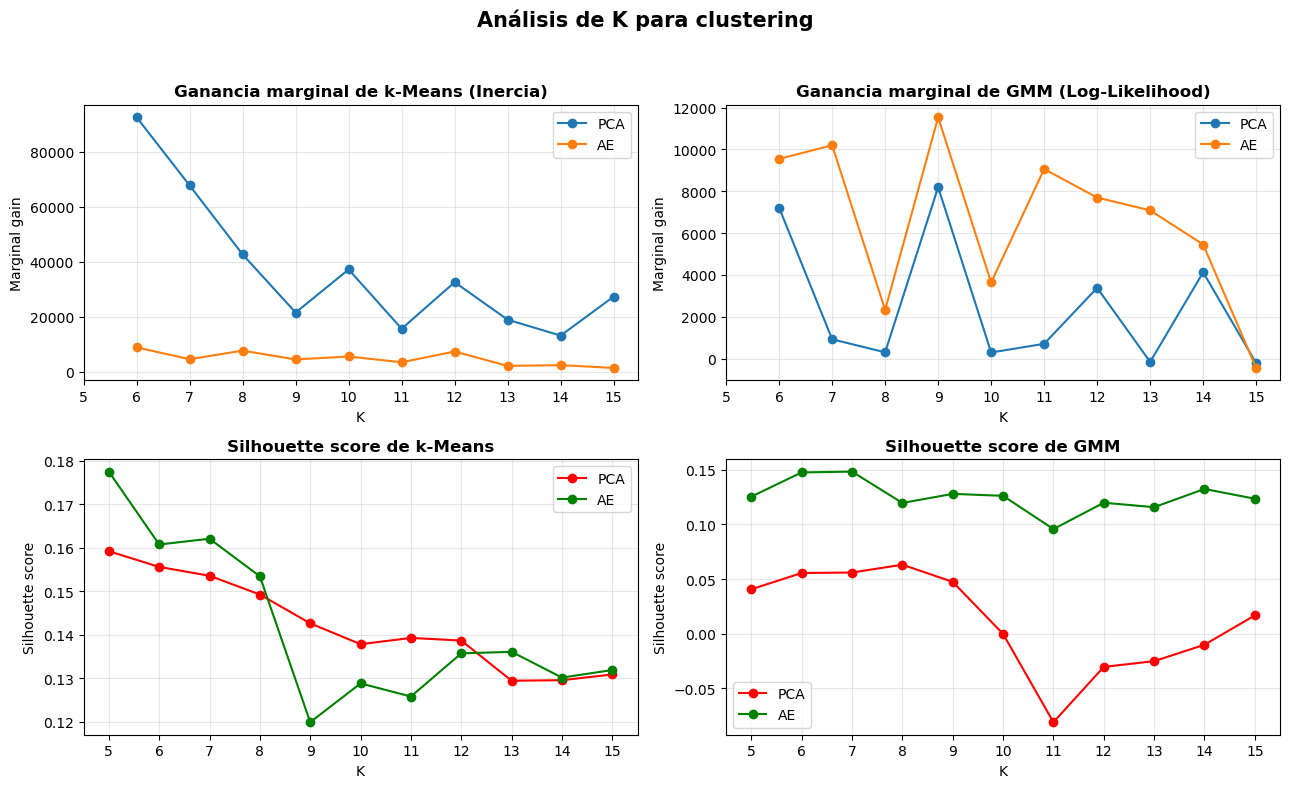

In [45]:
plot_clustering_k_analysis(kmeans_pca_gain, kmeans_ae_gain, gmm_pca_gain, gmm_ae_gain, kmeans_pca_silhouette, kmeans_ae_silhouette, gmm_pca_silhouette, gmm_ae_silhouette)

Para analizar el desempeño con distintos valores de $K$, se usaron dos criterios: la ganancia marginal y el Silhouette score. La ganancia marginal muestra cuánto mejora el modelo al aumentar $K$ y funciona como una forma de aplicar el método del codo: se busca ver a partir de qué valor agregar más clusters empieza a aportar menos. Por otro lado, el Silhouette score mide qué tan compactos y separados quedan los clusters.

En k-Means, la ganancia marginal es alta al pasar de $K=5$ a $K=6$, especialmente en PCA, y luego empieza a volverse más baja e irregular. Esto indica que agregar clusters mejora el ajuste, pero no aparece un codo completamente claro.

La ganancia marginal no permite evaluar directamente $K=5$, porque se calcula como la mejora al pasar de $K-1$ a $K$. Sin embargo, el Silhouette score sí está definido para $K=5$ y alcanza allí su valor máximo, tanto para PCA como para AE. Esto sugiere que, dentro del rango analizado, $K=5$ genera los clusters más compactos y mejor separados. Por eso, se toma $K=5$ como una elección razonable para k-Means.

En GMM, la ganancia marginal es más irregular, con picos marcados en algunos valores intermedios, como $K=9$ y $K=11$. Esto muestra que ciertos aumentos de $K$ mejoran el log-likelihood, pero no necesariamente implican clusters más claros. Al mirar el Silhouette score, el espacio latente del AE da resultados más estables y positivos que PCA. Los valores más altos aparecen alrededor de $K=6$ y $K=7$, por lo que esos valores parecen mejores candidatos para GMM. Entre ellos, $K=7$ resulta una opción razonable porque mantiene un Silhouette alto y se apoya en una mejora marginal todavía importante.

En conjunto, las curvas no sugieren que $K=10$ sea necesariamente el mejor valor, aunque el dataset tenga 10 clases reales. Esto tiene sentido porque los métodos no supervisados no utilizan las etiquetas, sino que agrupan según la estructura geométrica de los datos. Algunas clases visualmente parecidas, como remera, camisa, pulóver y abrigo, pueden quedar dentro de un mismo cluster. Por eso, se elige $K=5$ para k-Means y $K=7$ para GMM como valores razonables según las métricas observadas.

### d) Calidad de los clusters

In [46]:
# Chosen K
k_kmeans = 5
k_gmm = 7

In [47]:
# Labels
best_labels_kmeans = kmeans_pca_results[k_kmeans]["labels"]
best_labels_gmm = gmm_pca_results[k_gmm]["labels"]

In [ ]:
print("K elegido para K-Means:", k_kmeans)
print("Cantidad de muestras:", len(best_labels_kmeans))
print()
print("K elegido para GMM:", k_gmm)
print("Cantidad de muestras:", len(best_labels_gmm))

K elegido para K-Means: 5
Cantidad de muestras: 3000

K elegido para GMM: 7
Cantidad de muestras: 3000


: 

In [ ]:
xtr_pca_tsne = tsne(xtr_pca_sample, n_iters = 300, verbose = False)

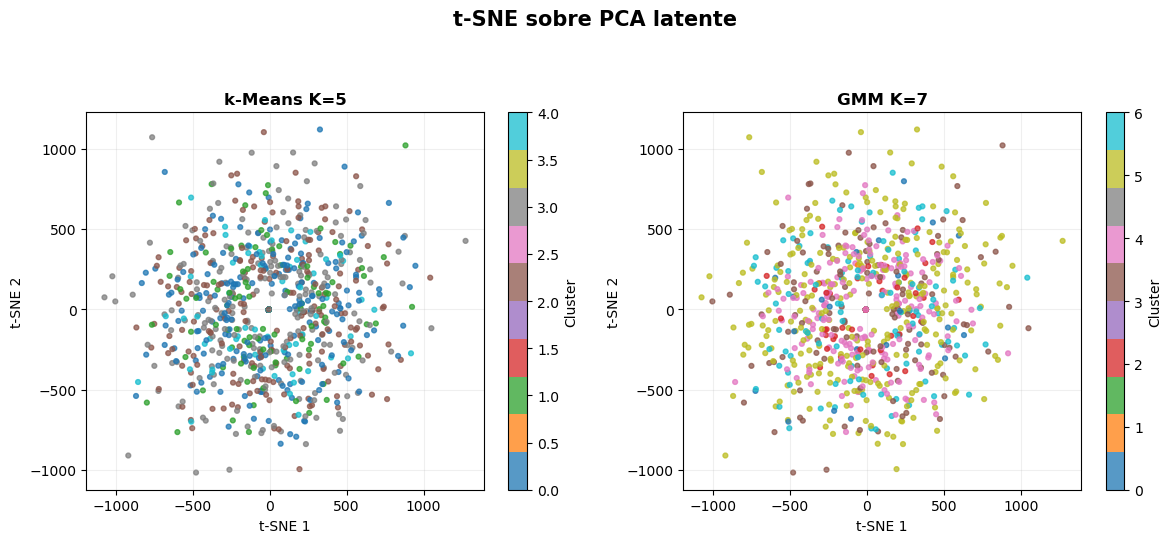

In [ ]:
plot_tsne_cluster_comparison(xtr_pca_tsne, best_labels_kmeans, best_labels_gmm, title_1=f"k-Means K={k_kmeans}", title_2=f"GMM K={k_gmm}", general_title="t-SNE sobre PCA latente")

In [ ]:
kmeans_cluster_size_table = build_cluster_size_table(best_labels_kmeans)
kmeans_cluster_class_table = build_cluster_class_table(best_labels_kmeans, ytr_sample)
kmeans_cluster_purity_table = build_cluster_purity_table(best_labels_kmeans, ytr_sample)

cluster,count,percentage
0,801,26.700000
1,365,12.170000
2,774,25.800000
3,799,26.630000
4,261,8.700000


,0: T-shirt/top,1: Trouser,2: Pullover,3: Dress,4: Coat,5: Sandal,6: Shirt,7: Sneaker,8: Bag,9: Ankle boot
cluster,,,,,,,,,,
0,120,8,208,24,228,0,160,0,51,2
1,2,0,2,0,1,22,0,101,123,114
2,136,279,11,238,38,1,53,0,15,3
3,40,13,77,38,31,255,84,199,51,11
4,2,0,2,0,2,22,3,0,60,170


cluster,size,dominant_class,dominant_count,purity
0,801,4: Coat,228,0.284600
1,365,8: Bag,123,0.337000
2,774,1: Trouser,279,0.360500
3,799,5: Sandal,255,0.319100
4,261,9: Ankle boot,170,0.651300


In [ ]:
gmm_cluster_size_table = build_cluster_size_table(best_labels_gmm)
gmm_cluster_class_table = build_cluster_class_table(best_labels_gmm, ytr_sample)
gmm_cluster_purity_table = build_cluster_purity_table(best_labels_gmm, ytr_sample)

cluster,count,percentage
0,66,2.200000
1,3,0.100000
2,194,6.470000
3,432,14.400000
4,877,29.230000
5,1035,34.500000
6,393,13.100000


,0: T-shirt/top,1: Trouser,2: Pullover,3: Dress,4: Coat,5: Sandal,6: Shirt,7: Sneaker,8: Bag,9: Ankle boot
cluster,,,,,,,,,,
0,0,0,0,0,0,0,0,0,66,0
1,0,0,0,0,0,3,0,0,0,0
2,11,2,7,0,2,17,13,0,98,44
3,0,0,0,0,0,150,1,256,0,25
4,76,35,89,50,68,116,72,38,126,207
5,208,13,204,115,229,14,212,6,10,24
6,5,250,0,135,1,0,2,0,0,0


cluster,size,dominant_class,dominant_count,purity
0,66,8: Bag,66,1.000000
1,3,5: Sandal,3,1.000000
2,194,8: Bag,98,0.505200
3,432,7: Sneaker,256,0.592600
4,877,9: Ankle boot,207,0.236000
5,1035,4: Coat,229,0.221300
6,393,1: Trouser,250,0.636100


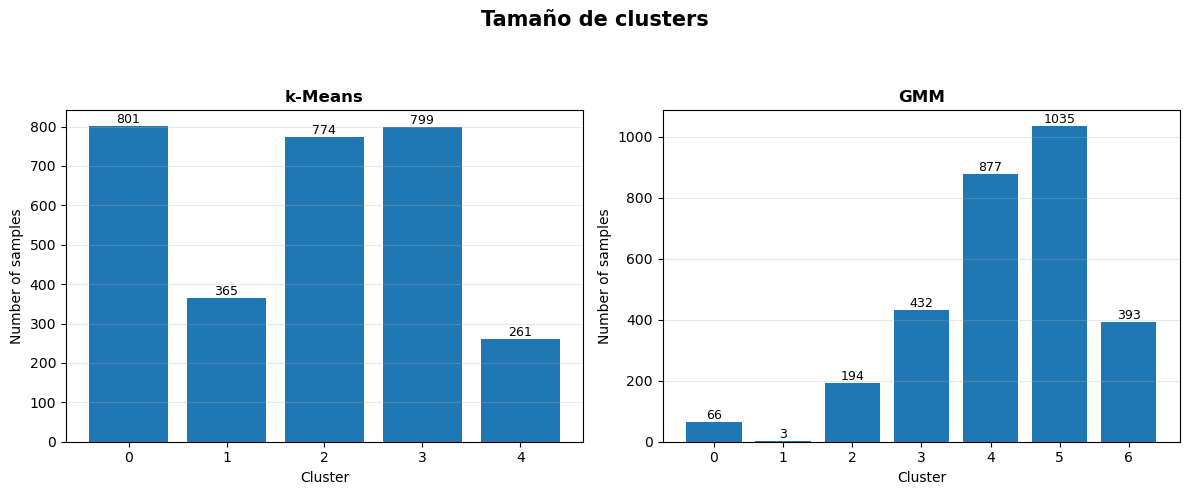

/home/abril/UdeSA/ML/TP4_ML/src/graphics.py:650: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0, 1, 0.92))


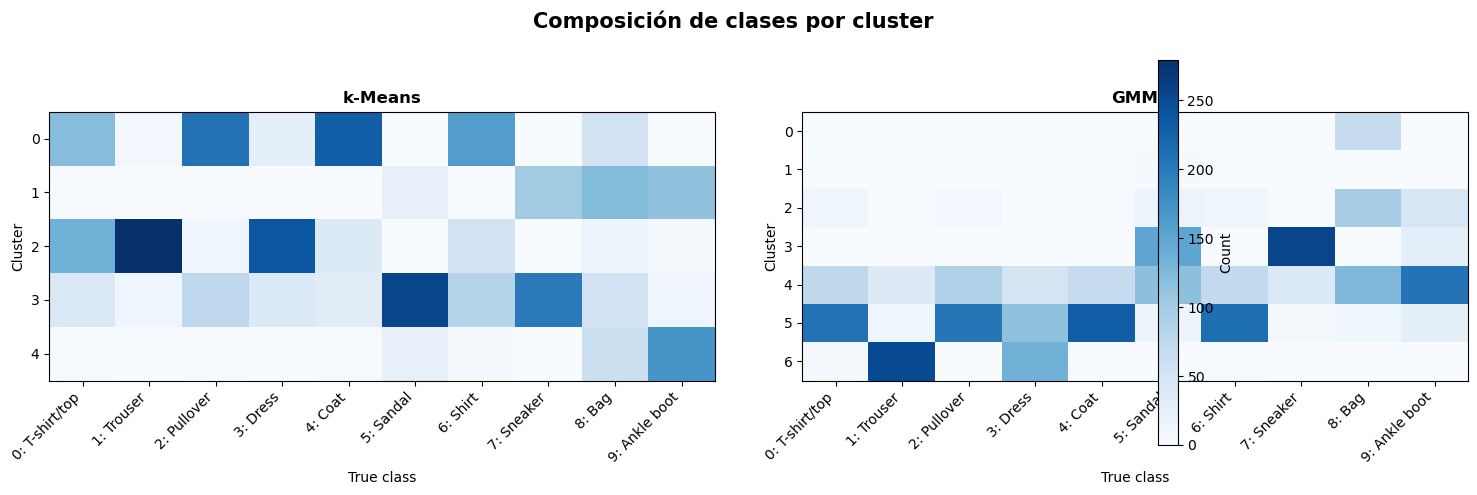

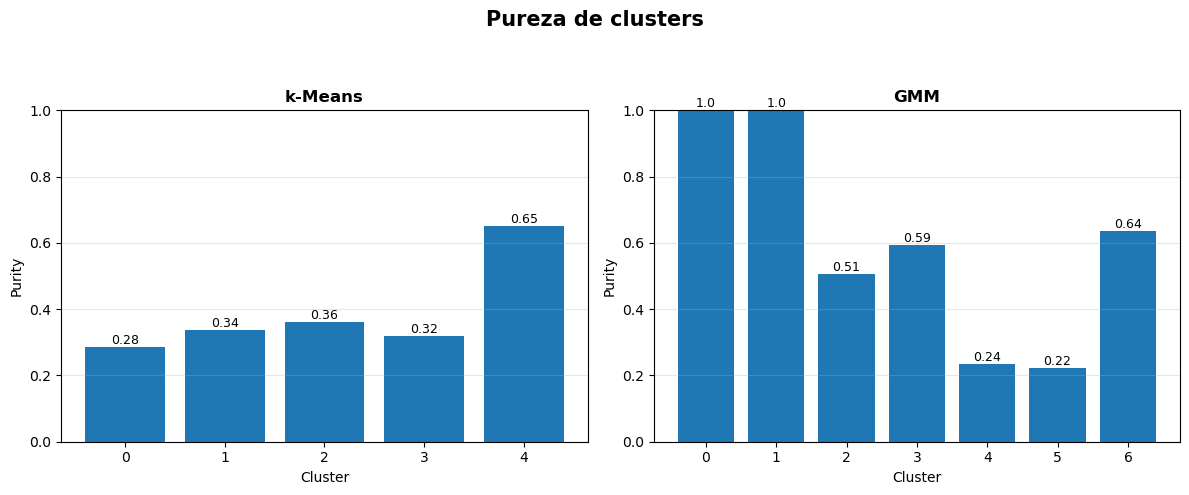

In [ ]:
plot_cluster_size_comparison(kmeans_cluster_size_table, gmm_cluster_size_table)
plot_cluster_class_heatmap_comparison(kmeans_cluster_class_table, gmm_cluster_class_table)
plot_cluster_purity_comparison(kmeans_cluster_purity_table, gmm_cluster_purity_table)

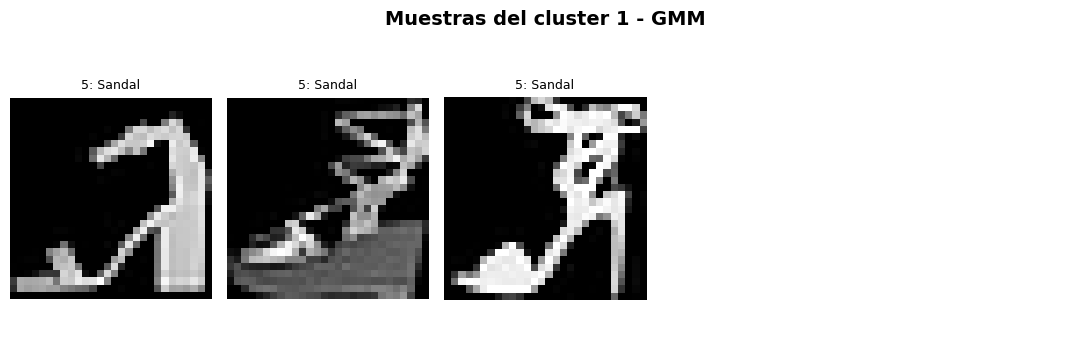

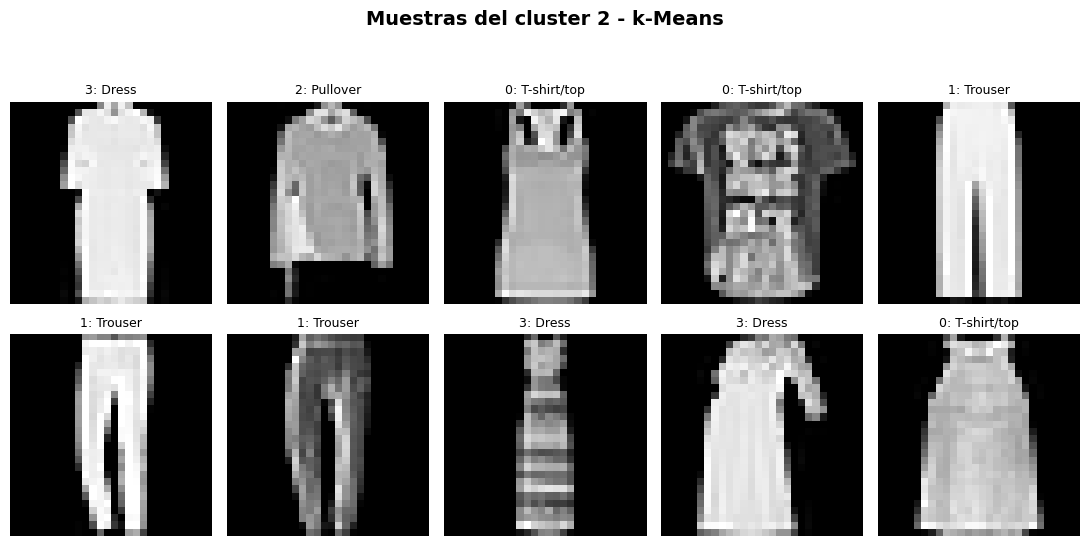

In [ ]:
xtr_original_sample = xtr.iloc[sample_indices]
ytr_original_sample = ytr.iloc[sample_indices]

plot_images_by_cluster(xtr_original_sample, best_labels_gmm, ytr_original_sample, 
                       cluster_id = 1, n_images=10, title="Muestras del cluster 1 - GMM")
plot_images_by_cluster(xtr_original_sample, best_labels_kmeans, ytr_original_sample,
                       cluster_id = 2, n_images=10, title="Muestras del cluster 2 - k-Means") 